In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

data = pd.read_csv("horse_colic_normalized.csv", delimiter=",")

df_reduced = pd.read_csv(
    "horse_colic_reduced_encoded.csv",
    delimiter=","
)

target_col = "outcome"

data = data.dropna(subset=[target_col])
df_reduced = df_reduced.dropna(subset=[target_col])

In [2]:
X = data.drop(columns=[target_col])
y = data[target_col]

X = X.fillna(X.median())

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


X_reduced = df_reduced.drop(columns=[target_col])
y_reduced = df_reduced[target_col]

X_reduced = X_reduced.fillna(X_reduced.median())

X_train_reduced, X_test_reduced, y_train_reduced, y_test_reduced = train_test_split(
    X_reduced,
    y_reduced,
    test_size=0.2,
    random_state=42,
    stratify=y_reduced
)

In [3]:
base_learners = [
    ('rf', RandomForestClassifier(n_estimators=150, random_state=42)),
    ('gb', GradientBoostingClassifier(n_estimators=150, random_state=42)),
    ('svc', SVC(probability=True, random_state=42))
]

stacking_model = StackingClassifier(
    estimators=base_learners,
    final_estimator=LogisticRegression(max_iter=1000),
    cv=5
)

stacking_model.fit(X_train, y_train)

y_pred = stacking_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy of Stacking Classifier: {accuracy:.2f}")


stacking_model_reduced = StackingClassifier(
    estimators=base_learners,
    final_estimator=LogisticRegression(max_iter=1000),
    cv=5
)

stacking_model_reduced.fit(X_train_reduced, y_train_reduced)

y_pred_reduced = stacking_model_reduced.predict(X_test_reduced)

accuracy_reduced = accuracy_score(y_test_reduced, y_pred_reduced)

print(f"Accuracy of Stacking Classifier reduced: {accuracy_reduced:.2f}")

Accuracy of Stacking Classifier: 0.72
Accuracy of Stacking Classifier reduced: 0.72


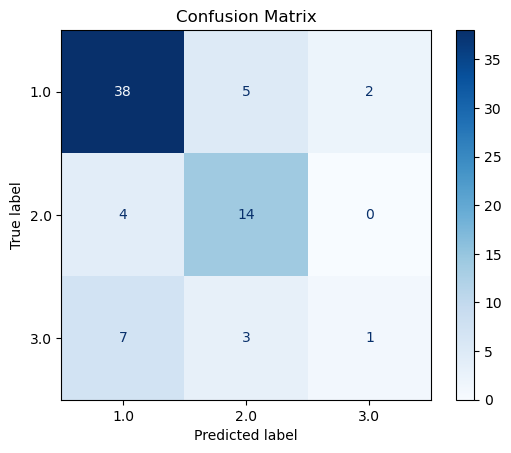

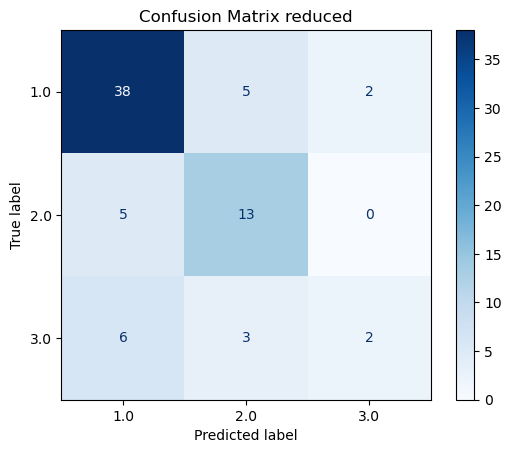

In [4]:
conf_matrix = confusion_matrix(y_test, y_pred)

display = ConfusionMatrixDisplay(
    conf_matrix,
    display_labels=stacking_model.classes_
)

display.plot(cmap='Blues')

plt.title("Confusion Matrix")
plt.show()


conf_matrix_reduced = confusion_matrix(y_test_reduced, y_pred_reduced)

display_reduced = ConfusionMatrixDisplay(
    conf_matrix_reduced,
    display_labels=stacking_model_reduced.classes_
)

display_reduced.plot(cmap='Blues')

plt.title("Confusion Matrix reduced")
plt.show()

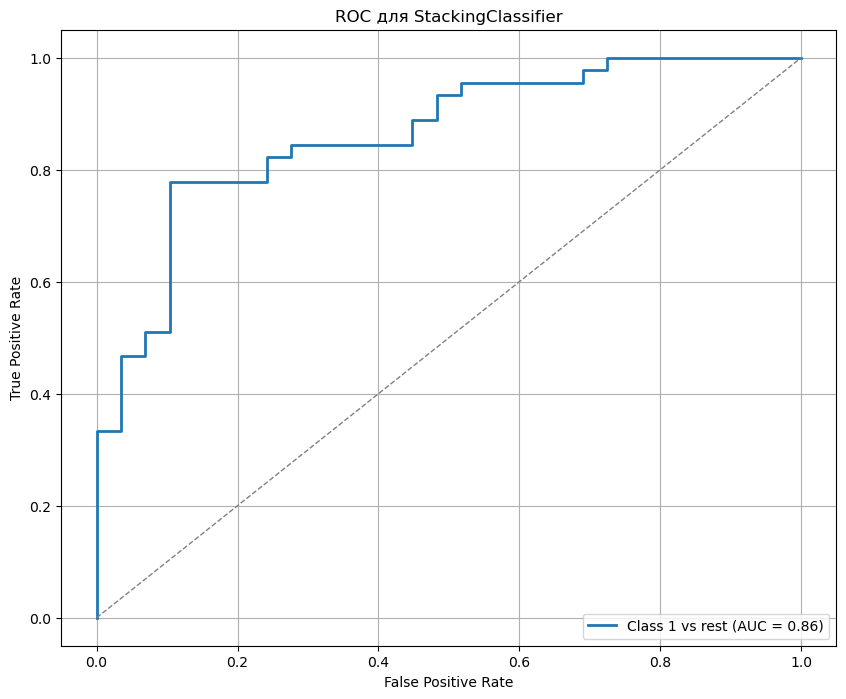

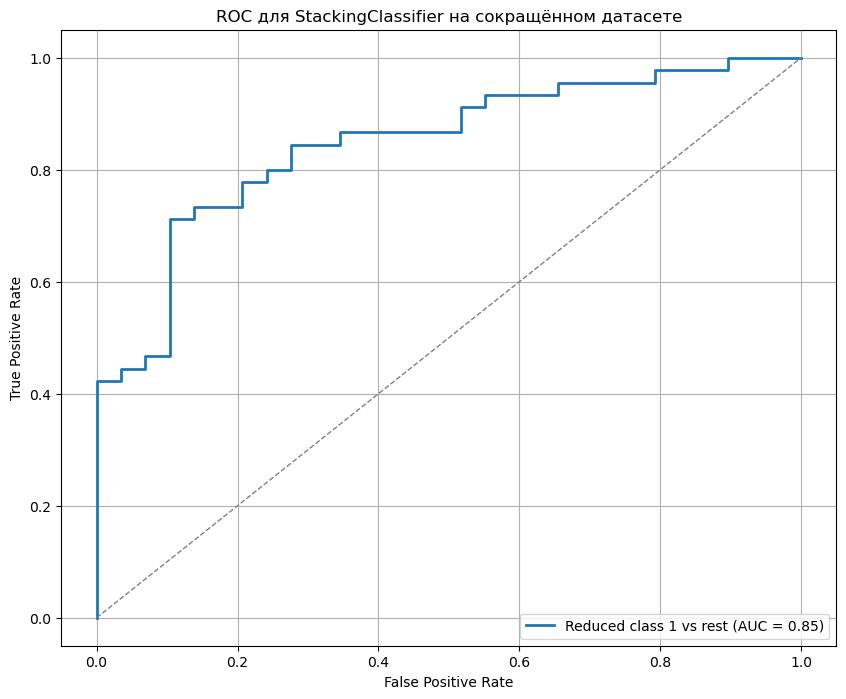

In [5]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

positive_class = 1

y_test_binary = (y_test == positive_class).astype(int)

positive_class_index = list(stacking_model.classes_).index(positive_class)

y_prob = stacking_model.predict_proba(X_test)[:, positive_class_index]

fpr, tpr, _ = roc_curve(y_test_binary, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, lw=2, label=f'Class {positive_class} vs rest (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='grey', linestyle='--', lw=1)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC для StackingClassifier')
plt.legend(loc='lower right')
plt.grid()
plt.show()


y_test_reduced_binary = (y_test_reduced == positive_class).astype(int)

positive_class_index_reduced = list(stacking_model_reduced.classes_).index(positive_class)

y_prob_reduced = stacking_model_reduced.predict_proba(X_test_reduced)[:, positive_class_index_reduced]

fpr_reduced, tpr_reduced, _ = roc_curve(
    y_test_reduced_binary,
    y_prob_reduced
)

roc_auc_reduced = auc(fpr_reduced, tpr_reduced)

plt.figure(figsize=(10, 8))
plt.plot(
    fpr_reduced,
    tpr_reduced,
    lw=2,
    label=f'Reduced class {positive_class} vs rest (AUC = {roc_auc_reduced:.2f})'
)

plt.plot([0, 1], [0, 1], color='grey', linestyle='--', lw=1)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC для StackingClassifier на сокращённом датасете')
plt.legend(loc='lower right')
plt.grid()
plt.show()

In [7]:
import numpy as np

coefficients = pd.DataFrame({
    'Classifier': stacking_model.get_feature_names_out(),
    'Coefficient': np.mean(
        np.abs(stacking_model.final_estimator_.coef_),
        axis=0
    )
})

coefficients['Classifier'] = coefficients['Classifier'].replace({
    'stackingclassifier_rf': 'RandomForestClassifier',
    'stackingclassifier_gb': 'GradientBoostingClassifier',
    'stackingclassifier_svc': 'SVC'
})

coefficients = coefficients.sort_values(
    by='Coefficient',
    ascending=False
)

print(coefficients)

print(f"Наиболее важен: {coefficients.iloc[0]['Classifier']}")


coefficients_reduced = pd.DataFrame({
    'Classifier': stacking_model_reduced.get_feature_names_out(),
    'Coefficient': np.mean(
        np.abs(stacking_model_reduced.final_estimator_.coef_),
        axis=0
    )
})

coefficients_reduced['Classifier'] = coefficients_reduced['Classifier'].replace({
    'stackingclassifier_rf': 'RandomForestClassifier',
    'stackingclassifier_gb': 'GradientBoostingClassifier',
    'stackingclassifier_svc': 'SVC'
})

coefficients_reduced = coefficients_reduced.sort_values(
    by='Coefficient',
    ascending=False
)

print(coefficients_reduced)

print(
    f"Наиболее важен для сокращённого датасета: "
    f"{coefficients_reduced.iloc[0]['Classifier']}"
)

                Classifier  Coefficient
0   stackingclassifier_rf0     1.398226
1   stackingclassifier_rf1     1.208933
2   stackingclassifier_rf2     0.871261
5   stackingclassifier_gb2     0.566301
4   stackingclassifier_gb1     0.428269
8  stackingclassifier_svc2     0.312338
7  stackingclassifier_svc1     0.236568
3   stackingclassifier_gb0     0.120581
6  stackingclassifier_svc0     0.100472
Наиболее важен: stackingclassifier_rf0
                Classifier  Coefficient
0   stackingclassifier_rf0     1.310852
2   stackingclassifier_rf2     0.860835
1   stackingclassifier_rf1     0.808229
5   stackingclassifier_gb2     0.646935
4   stackingclassifier_gb1     0.505446
8  stackingclassifier_svc2     0.235407
7  stackingclassifier_svc1     0.156258
6  stackingclassifier_svc0     0.143602
3   stackingclassifier_gb0     0.135737
Наиболее важен для сокращённого датасета: stackingclassifier_rf0
